# 03 - The Pricing MDP

This notebook demonstrates the environment defined in `src/environment.py` and checks it
behaves as the formulation says it should. Nothing is redefined here - the simulator, the
dynamic program and the MILP all import the same module, so there is a single description
of the model.

## Formulation

A selling season for one (hotel, month) is a finite-horizon MDP `<S, A, P, R, gamma, H>`
with `H = 12` weekly decision epochs, week 0 being twelve weeks before arrival.

**State** `s = (weeks_remaining, occupancy_bin, regime)`

* `weeks_remaining in {0..12}` - selling time left
* `occupancy_bin in {0..9}` - rooms sold as a decile of capacity (inventory level)
* `regime in {soft, normal, strong}` - market conditions (external factor)

**Action** `a in {0..5}`, a multiplier in `{0.70, 0.85, 1.00, 1.15, 1.30, 1.45}` applied
to the reference rate.

**Transition** with `K ~ Poisson(lambda(w, g, a))`, `lambda = base[w] * phi[g] * m_a^(-eps)`:

    rooms_sold' = min(rooms_sold + K, capacity),    regime' ~ P_regime[regime, .]

**Reward** `R = sold * rate * L * (1 - p_cancel[w]) - c * turned_away * rate`

**Constraints** one rate per week; rate confined to `[0.70, 1.45] x reference`; cumulative
sales bounded by capacity.

`gamma = 1` - the horizon is finite and short, so revenue is not discounted.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour
use_style()

from config import MULTIPLIERS, HORIZON, N_OCC_BINS, N_REGIMES, REGIME_NAMES
from environment import HotelPricingEnv

env = HotelPricingEnv("City Hotel", "May", seed=0)
print(f"reference rate   {env.ref_price:,.0f}")
print(f"capacity         {env.capacity:,} rooms")
print(f"elasticity       {env.elasticity:.2f}   (estimated)")
print(f"competitor index {env.competitor_index:.2f}")
print(f"state space      {env.n_states} = {np.prod(env.n_states)} states x {env.n_actions} actions")

reference rate   120
capacity         1,894 rooms
elasticity       3.16   (estimated)
competitor index 0.62
state space      (13, 10, 3) = 390 states x 6 actions


## 1. The cancellation curve runs the right way

Decision week 0 sits eleven weeks before arrival and week 11 *is* the arrival week, so the
lead time attached to week `w` is `(H - 1 - w) * 7` days. Getting this mapping backwards
silently inverts the curve and mis-weights the most valuable week of the season, so it is
asserted rather than eyeballed.

In [2]:
from scipy import stats

rho = stats.spearmanr(np.arange(HORIZON), env.weekly_pcancel).statistic
assert rho < 0, "cancellation risk must fall as arrival approaches"
assert env.weekly_pcancel[0] > env.weekly_pcancel[-1]
print(f"P(cancel) 11 weeks out : {env.weekly_pcancel[0]:.3f}")
print(f"P(cancel) arrival week : {env.weekly_pcancel[-1]:.3f}")
print(f"Spearman(week, P(cancel)) = {rho:.3f}   -> risk falls toward arrival, as observed")

P(cancel) 11 weeks out : 0.407
P(cancel) arrival week : 0.101
Spearman(week, P(cancel)) = -0.540   -> risk falls toward arrival, as observed


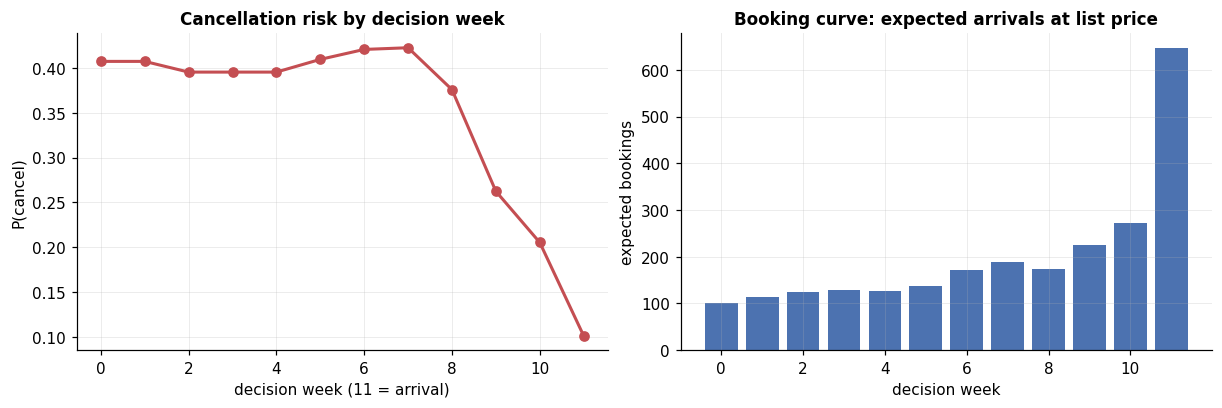

total demand at list price 2,410 vs capacity 1,894  ->  capacity binds, so inventory has scarcity value


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(range(HORIZON), env.weekly_pcancel, "o-", color="#c44e52", lw=2)
axes[0].set(title="Cancellation risk by decision week", xlabel="decision week (11 = arrival)",
            ylabel="P(cancel)")
axes[1].bar(range(HORIZON), env.weekly_base, color="#4c72b0")
axes[1].set(title="Booking curve: expected arrivals at list price",
            xlabel="decision week", ylabel="expected bookings")
save_fig("03_env_primitives")
plt.show()
print(f"total demand at list price {env.weekly_base.sum():,.0f} vs capacity {env.capacity:,}"
      f"  ->  capacity binds, so inventory has scarcity value")

## 2. Demand response and the transition kernel

Price enters through the constant-elasticity term and the regime multiplies it. The
right-hand panel shows the actual transition kernel `P(rooms sold next week | now)` - the
Poisson arrival distribution that `src/mdp.py` uses to solve the model exactly.

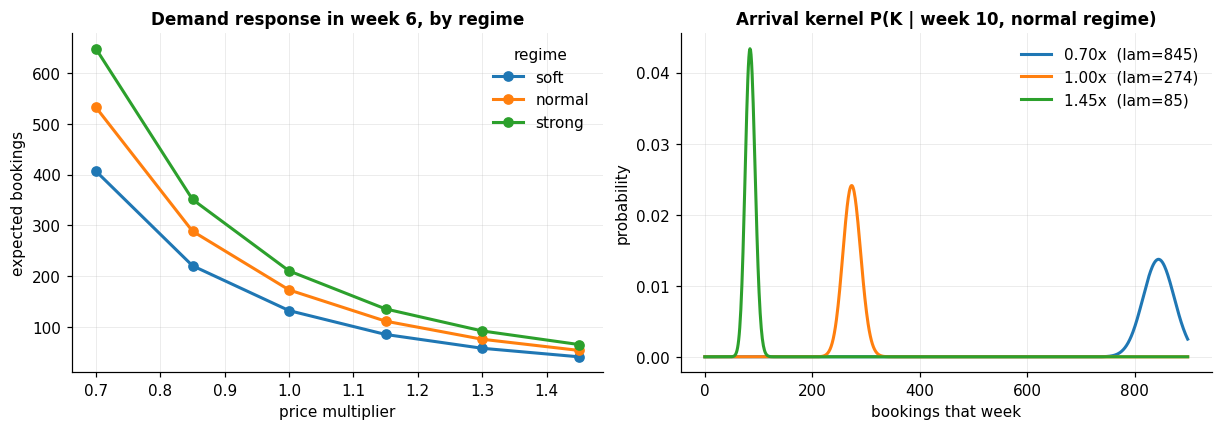

In [4]:
from scipy.stats import poisson

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for g in range(N_REGIMES):
    axes[0].plot(MULTIPLIERS, [env.expected_demand(6, g, a) for a in range(env.n_actions)],
                 "o-", lw=2, label=REGIME_NAMES[g])
axes[0].set(title="Demand response in week 6, by regime", xlabel="price multiplier",
            ylabel="expected bookings")
axes[0].legend(title="regime")

for a in [0, 2, 5]:
    lam = env.expected_demand(10, 1, a)
    k = np.arange(0, 900)
    axes[1].plot(k, poisson.pmf(k, lam), lw=2, label=f"{MULTIPLIERS[a]:.2f}x  (lam={lam:.0f})")
axes[1].set(title="Arrival kernel P(K | week 10, normal regime)", xlabel="bookings that week",
            ylabel="probability")
axes[1].legend()
save_fig("03_transition_kernel")
plt.show()

## 3. A sample season

One trajectory under list pricing, showing how inventory, rate and market regime interact.

In [5]:
env.set_common_randoms(None, None)
state = env.reset()
rows, done = [], False
while not done:
    week, occ_bin, regime = state
    state, reward, done, info = env.step(2)   # list price every week
    rows.append({"week": HORIZON - week, "regime": REGIME_NAMES[regime],
                 "multiplier": info["multiplier"], "sold": info["sold_now"],
                 "cumulative": env.sold, "turned away": info["turned_away"],
                 "reward": round(reward)})
pd.DataFrame(rows)

,week,regime,multiplier,sold,cumulative,turned away,reward
0,0,soft,1.0,55,55,0,11734
1,1,normal,1.0,132,187,0,28161
2,2,strong,1.0,153,340,0,33299
3,3,strong,1.0,144,484,0,31341
4,4,strong,1.0,148,632,0,32211
5,5,soft,1.0,92,724,0,19553
6,6,normal,1.0,177,901,0,36910
7,7,strong,1.0,237,1138,0,49262
8,8,strong,1.0,194,1332,0,43590
9,9,strong,1.0,266,1598,0,70632


## 4. Constant-price benchmark

Sweeping the action grid with a fixed rate shows the tension the agent must resolve: at or
below list price the hotel sells out but leaves rate on the table; above 1.15x it protects
rate but ends the season with empty rooms. The best constant price sits at the turning
point - and a policy that *reacts* to how the season unfolds should beat it.

In [6]:
from metrics import compare, draw_common_randoms
import policies as P

sweep_env = HotelPricingEnv("City Hotel", "May", seed=0)
fixed = {f"{m:.2f}x": P.fixed_policy(a) for a, m in enumerate(MULTIPLIERS)}
sweep, _ = compare(sweep_env, fixed, n_episodes=600, seed=4242)
sweep[["net_revenue", "occupancy", "adr", "sell_out_rate", "turned_away"]].round(2)

,net_revenue,occupancy,adr,sell_out_rate,turned_away
strategy,,,,,
0.70x,284151.47,1.00,50.35,1.00,228.87
0.85x,343210.14,1.00,60.70,1.00,163.97
1.00x,448603.70,1.00,79.68,1.00,340.66
1.15x,456241.57,0.82,98.31,0.01,0.26
1.30x,350266.72,0.55,111.14,0.00,0.00
1.45x,276750.68,0.39,123.97,0.00,0.00


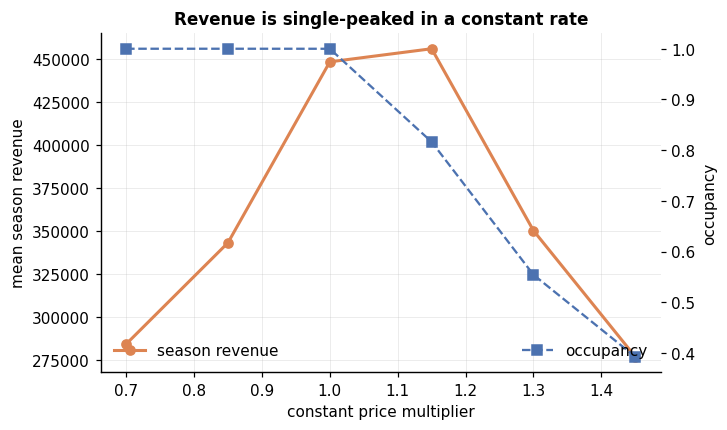

best constant price: 1.15x -> 456,242


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(MULTIPLIERS, sweep["net_revenue"], "o-", color="#dd8452", lw=2, label="season revenue")
ax.set(xlabel="constant price multiplier", ylabel="mean season revenue",
       title="Revenue is single-peaked in a constant rate")
twin = ax.twinx()
twin.plot(MULTIPLIERS, sweep["occupancy"], "s--", color="#4c72b0", lw=1.5, label="occupancy")
twin.set_ylabel("occupancy"); twin.grid(False)
ax.legend(loc="lower left"); twin.legend(loc="lower right")
save_fig("03_fixed_price_sweep")
plt.show()
best = sweep["net_revenue"].idxmax()
print(f"best constant price: {best} -> {sweep.loc[best, 'net_revenue']:,.0f}")